# Analys av winrate över en spelsession

Syftet med denna analys är att undersöka om spelarens winrate påverkas av hur långt in i en spelsession en match spelas.

## Forskningsfråga

Påverkas spelarens winrate av matchnumret i en spelsession?

## Hypoteser

**Nollhypotes (H₀):**
Winraten är oberoende av matchnumret i sessionen.

**Alternativhypotes (Hₐ):**
Winraten varierar beroende på matchnumret i sessionen.

För att undersöka detta analyseras först winraten för varje matchnummer. Därefter används statistiska tester för att identifiera eventuella skillnader och trender över sessionens gång.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway, kruskal
import statsmodels.api as sm



# Läser in data.
df = pd.read_csv("Data/Sessions/winrate_summary.csv")

# Konverterar True/false värden till numreriska värden.
df = df.astype(float)

C:\Users\gimsb\AppData\Local\Temp\ipykernel_32804\1187029221.py:10: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Data/Sessions/winrate_summary.csv")


In [2]:

# Konverterar datan´från wide format till long format, dvs att vi vill få en kolumn för matchnummer ock en för utfallet.
# Detta gör vi för att kunna utföra våra statistiska tester.


long_df = df.melt(
    var_name="game_in_session",
    value_name="win"
).dropna()

long_df["game_in_session"] = long_df["game_in_session"].astype(int)
long_df["win"] = long_df["win"].astype(int)

In [3]:

# Beräknar sammanfattande statestik.


# För varje session beräknas winrate, antal matcher och antal vinster.
summary = (
    long_df
    .groupby("game_in_session")
    .agg(
        winrate=("win", "mean"),
        n=("win", "count"),
        wins=("win", "sum")
    )
    .reset_index()
)

# Antal förluster beräknas som totalt antal matcher minus antal vinster.
summary["losses"] = summary["n"] - summary["wins"]

# Beräkna standardfel för winrate.
# Detta används för att uppskatta osäkerheten kring varje winrate.
summary["standard_error"] = np.sqrt(
    summary["winrate"] * (1 - summary["winrate"]) / summary["n"]
)

# Beräkna 95 % konfidensintervall.
summary["ci95"] = 1.96 * summary["standard_error"]
summary["lower_ci"] = summary["winrate"] - summary["ci95"]
summary["upper_ci"] = summary["winrate"] + summary["ci95"]

print("\nSummary statistics:")
print(summary)


Summary statistics:
    game_in_session   winrate       n   wins  losses  standard_error  \
0                 1  0.492269  124111  61096   63015        0.001419   
1                 2  0.497420   81406  40493   40913        0.001752   
2                 3  0.498442   49428  24637   24791        0.002249   
3                 4  0.500099   30224  15115   15109        0.002876   
4                 5  0.492620   19039   9379    9660        0.003623   
5                 6  0.500286   12259   6133    6126        0.004516   
6                 7  0.491519    8136   3999    4137        0.005542   
7                 8  0.492255    5552   2733    2819        0.006710   
8                 9  0.489637    3860   1890    1970        0.008046   
9                10  0.505439    2758   1394    1364        0.009520   
10               11  0.526214    2060   1084     976        0.011001   
11               12  0.514706    1496    770     726        0.012922   
12               13  0.497750    1111    55

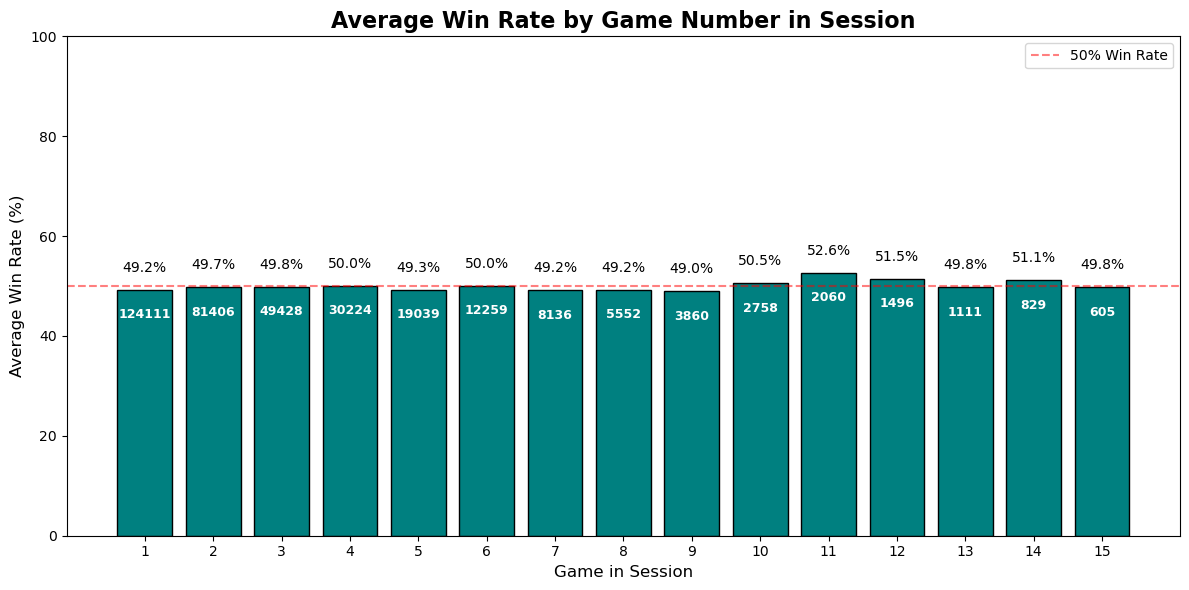

In [4]:
# Visualisera winrate per matchnummer.

plt.figure(figsize=(12, 6))

bars = plt.bar(
    summary["game_in_session"],
    summary["winrate"] * 100,
    color="teal",
    edgecolor="black",
)

plt.title(
    "Average Win Rate by Game Number in Session", fontsize=16, fontweight="bold"
)
plt.xlabel("Game in Session", fontsize=12)
plt.ylabel("Average Win Rate (%)", fontsize=12)

plt.axhline(50, color="red", linestyle="--", alpha=0.5, label="50% Win Rate")
plt.ylim(0, 100)
plt.legend()


for bar, winrate, count in zip(bars, summary["winrate"], summary["n"]):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,  
        f"{winrate * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

    text_y = height - 5 if height > 10 else height + 2
    va_dir = "center" if height > 10 else "bottom"
    text_color = "white" if height > 15 else "black"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        text_y,
        f"{int(count)}",
        ha="center",
        va=va_dir,
        fontsize=9,
        color=text_color,
        fontweight="bold",
    )

plt.xticks(summary["game_in_session"])
plt.tight_layout()
plt.show()

## Chi-square-test

För att undersöka om winraten skiljer sig mellan olika matchnummer används ett Chi-square-test för oberoende.

### Hypoteser

**H₀:** Winraten är densamma för alla matchnummer i sessionen.

**Hₐ:** Minst ett matchnummer har en winrate som skiljer sig från övriga.

Om p-värdet är mindre än 0,05 förkastas nollhypotesen, vilket tyder på att matchnumret och matchutfallet inte är oberoende av varandra.

In [5]:

# Chi-square test
# Testet undersöker om matchnummer och matchutfall är oberoende av varandra.

# H0: Winraten är oberoende av matchnumret i sessionen.
# Ha: Winraten varierar beroende på matchnumret i sessionen.

contingency_table = summary[["wins", "losses"]]

chi2, chi_p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square test:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {chi_p_value:.4f}")

if chi_p_value < 0.05:
    print("Det finns en statistiskt signifikant skillnad i winrate mellan matchnummer.")
else:
    print("Ingen statistiskt signifikant skillnad i winrate mellan matchnummer hittades.")


Chi-square test:
Chi-square statistic: 25.5022
p-value: 0.0299
Det finns en statistiskt signifikant skillnad i winrate mellan matchnummer.


## Logistisk regression

För att undersöka om det finns en systematisk trend i winraten över en session används logistisk regression.

Modellen uppskattar hur sannolikheten att vinna förändras när matchnumret ökar.

### Tolkning
Positiv koefficient innebär att sannolikheten att vinna ökar längre in i sessionen.
Negativ koefficient innebär att sannolikheten att vinna minskar längre in i sessionen.
Ett p-värde under 0,05 indikerar att sambandet är statistiskt signifikant.

In [6]:

# Logistisk regression

# Logistisk regression används eftersom utfallet är binärt: vinst = 1 och förlust = 0.

# Modellen undersöker om sannolikheten att vinna förändras när matchnumret i sessionen ökar.

# Lägg till en konstant/intercept i modellen.
X = sm.add_constant(long_df["game_in_session"])

# Responsvariabeln är matchutfallet.
y = long_df["win"]

# Anpassa den logistiska regressionsmodellen.
logit_model = sm.Logit(y, X).fit()

print("\nLogistisk regression:")
print(logit_model.summary())

# Hämta koefficient, p-värde och odds ratio för matchnummer.
coef = logit_model.params["game_in_session"]
p_value = logit_model.pvalues["game_in_session"]
odds_ratio = np.exp(coef)

print("\nInterpretation:")
print(f"Coefficient for game number: {coef:.4f}")
print(f"Odds ratio: {odds_ratio:.4f}")
print(f"p-value: {p_value:.4f}")

# Tolka om det finns en statistiskt signifikant trend över sessionen.
if p_value < 0.05:
    if coef > 0:
        print("Slutsats: Sannolikheten att vinna ökar signifikant längre in i sessionen.")
    else:
        print("Slutsats: Sannolikheten att vinna minskar signifikant längre in i sessionen.")
else:
    print("Slutsats: Ingen statistiskt signifikant trend hittades över sessionen.")

Optimization terminated successfully.
         Current function value: 0.693104
         Iterations 3

Logistisk regression:
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:               342874
Model:                          Logit   Df Residuals:                   342872
Method:                           MLE   Df Model:                            1
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:               1.232e-05
Time:                        10:02:23   Log-Likelihood:            -2.3765e+05
converged:                       True   LL-Null:                   -2.3765e+05
Covariance Type:            nonrobust   LLR p-value:                   0.01554
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0267      0.005     -4.997      0.000      -0.037    